## Delivery Data


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
distances = np.asarray([1, 3, 5, 7, 9, 11])
time_taken = np.asarray([14, 22, 30, 41, 47, 55])

for distance, time in zip(distances, time_taken):
    print(f"Distance: {distance} km\t\t | \tTime: {time} minutes")

Distance: 1 km		 | 	Time: 14 minutes
Distance: 3 km		 | 	Time: 22 minutes
Distance: 5 km		 | 	Time: 30 minutes
Distance: 7 km		 | 	Time: 41 minutes
Distance: 9 km		 | 	Time: 47 minutes
Distance: 11 km		 | 	Time: 55 minutes


- `0` → Not late
- `1` → Late

In [6]:
late = np.asarray([0, 0, 0, 1, 1, 1])

for distance, label in zip(distances, late):
    status = "Late" if label == 1 else "Not late"
    print(f"Distance: {distance} km\t\t | \tLate: {status}")

Distance: 1 km		 | 	Late: Not late
Distance: 3 km		 | 	Late: Not late
Distance: 5 km		 | 	Late: Not late
Distance: 7 km		 | 	Late: Late
Distance: 9 km		 | 	Late: Late
Distance: 11 km		 | 	Late: Late


## Linear Regression Model


In [8]:
def predict(x, w, b):
    return w * x + b

In [9]:
def cost_function(x, y, w, b):
    predictions = [predict(xi, w, b) for xi in x]
    errors = [pred - actual for pred, actual in zip(predictions, y)]
    return sum(error ** 2 for error in errors) / len(x)

## Gradient Descent


In [10]:
def gradient_descent(x, y, learning_rate=0.01, iterations=20000):
    w = 0.0
    b = 0.0
    n = len(x)

    for _ in range(iterations):
        predictions = [predict(xi, w, b) for xi in x]

        dw = (2 / n) * sum(
            xi * (pred - actual)
            for xi, pred, actual in zip(x, predictions, y)
        )

        db = (2 / n) * sum(
            pred - actual
            for pred, actual in zip(predictions, y)
        )

        w -= learning_rate * dw
        b -= learning_rate * db

    return w, b


w, b = gradient_descent(distances, late)

print(f"w: {w:.4f}")
print(f"b: {b:.4f}")

w: 0.1286
b: -0.2714


## Predictions


In [12]:
print("Distance | Actual | Prediction")
print("---------|--------|-----------")

for distance, actual in zip(distances, late):
    prediction = predict(distance, w, b)
    print(f"{distance:>8} | {actual:>6} | {prediction:>10.3f}")

Distance | Actual | Prediction
---------|--------|-----------
       1 |      0 |     -0.143
       3 |      0 |      0.114
       5 |      0 |      0.371
       7 |      1 |      0.629
       9 |      1 |      0.886
      11 |      1 |      1.143


## Check One Prediction by Hand

For the order at 7 km

In [13]:
distance = 7

prediction = w * distance + b

print(f"prediction = {w:.4f} × 7 + ({b:.4f})")
print(f"prediction = {prediction:.4f}")

prediction = 0.1286 × 7 + (-0.2714)
prediction = 0.6286


## The Problem With the Straight Line


In [32]:
for distance in [1, 11, 13, 15]:
    prediction = predict(distance, w, b)
    print(f"Distance: {distance:>2} km -> {prediction:.3f}")

Distance:  1 km -> -0.143
Distance: 11 km -> 1.143
Distance: 13 km -> 1.400
Distance: 15 km -> 1.657


At 1 km, the model predicts a negative value.

At 15 km, the model predicts a value greater than 1.

If we interpret these values as probabilities, both are impossible. A probability must stay between 0 and 1.

## Why Rounding Does Not Fix It


In [15]:
for distance in [13, 15]:
    prediction = predict(distance, w, b)
    decision = 1 if prediction >= 0.5 else 0
    status = "Late" if decision == 1 else "Not late"

    print(
        f"Distance: {distance} km | "
        f"Prediction: {prediction:.3f} | "
        f"Decision: {status}"
    )

Distance: 13 km | Prediction: 1.400 | Decision: Late
Distance: 15 km | Prediction: 1.657 | Decision: Late


The threshold can still give us a yes/no decision, but the raw output is not a valid probability.

The problem is the shape of the straight line. It has no floor and no ceiling.

## The 0.5 Decision Threshold


In [33]:
threshold = 0.5

for distance in distances:
    prediction = predict(distance, w, b)
    decision = 1 if prediction >= threshold else 0
    status = "Late" if decision == 1 else "Not late"

    print(
        f"Distance: {distance:>2} km | "
        f"Output: {prediction:.3f} | "
        f"Decision: {status}"
    )

Distance:  1 km | Output: -0.143 | Decision: Not late
Distance:  3 km | Output: 0.114 | Decision: Not late
Distance:  5 km | Output: 0.371 | Decision: Not late
Distance:  7 km | Output: 0.629 | Decision: Late
Distance:  9 km | Output: 0.886 | Decision: Late
Distance: 11 km | Output: 1.143 | Decision: Late


The `0.5` threshold is a rule we choose. It is not something the linear model learned.

## Why We Need Something New


A straight line can produce values below 0 and above 1.

For classification, we want a model that can turn an unrestricted number into a value between 0 and 1.

That leads us to the **sigmoid function**.

## Sigmoid Preview


In [34]:
import math


def sigmoid(z):
    return 1 / (1 + math.exp(-z))


for z in [-5, -2, 0, 2, 5]:
    print(f"z = {z:>2} -> sigmoid(z) = {sigmoid(z):.4f}")

z = -5 -> sigmoid(z) = 0.0067
z = -2 -> sigmoid(z) = 0.1192
z =  0 -> sigmoid(z) = 0.5000
z =  2 -> sigmoid(z) = 0.8808
z =  5 -> sigmoid(z) = 0.9933


The sigmoid maps any real number to a value between 0 and 1.

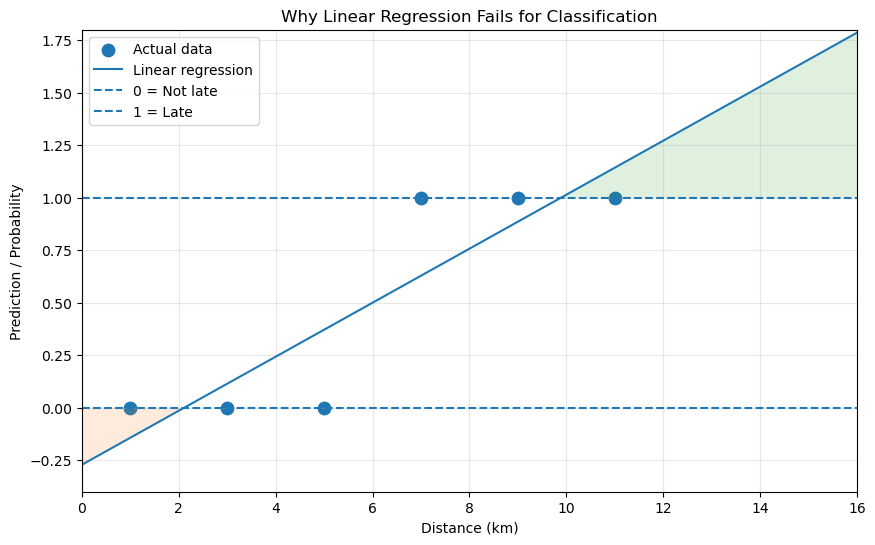

In [35]:

# Predictions from our trained linear regression model
x_values = np.linspace(0, 16, 200)
y_values = w * x_values + b

# Plot
plt.figure(figsize=(10, 6))

# Actual 0/1 data
plt.scatter(
    distances,
    late,
    s=80,
    label="Actual data"
)

# Linear regression line
plt.plot(
    x_values,
    y_values,
    label="Linear regression"
)

# Probability boundaries
plt.axhline(
    0,
    linestyle="--",
    label="0 = Not late"
)

plt.axhline(
    1,
    linestyle="--",
    label="1 = Late"
)


# Highlight invalid regions
plt.fill_between(
    x_values,
    y_values,
    0,
    where=(y_values < 0),
    alpha=0.15
)

plt.fill_between(
    x_values,
    y_values,
    1,
    where=(y_values > 1),
    alpha=0.15
)

# Labels
plt.xlabel("Distance (km)")
plt.ylabel("Prediction / Probability")
plt.title("Why Linear Regression Fails for Classification")

plt.xlim(0, 16)
plt.ylim(-0.4, 1.8)

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()